# Pengukuran Jarak (Dissimilarity Matrix) 
Mengimplementasikan pengukuran jarak antar objek data berdasarkan file **IRIS.csv** dengan merujuk pada materi **"Mengukur Jarak"**.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import MinMaxScaler

# Dataset
df = pd.read_csv('IRIS.csv')

# Data Deskriptif
print("--- Statistik Deskriptif ---")
display(df.describe())

# Memisahkan fitur numerik
X = df.drop(columns=['species'])


--- Statistik Deskriptif ---


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## **Normalisasi Data**
fitur numerik harus dinormalisasi. Kita menggunakan rumus:
$$z_{if} = \frac{x_{if} - min_f}{max_f - min_f}$$
Langkah ini memastikan semua fitur (sepal/petal) berada dalam rentang [0, 1].

In [2]:
scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X)

X_norm_df = pd.DataFrame(X_norm, columns=X.columns)
print("Data setelah Normalisasi (5 Baris Pertama):")
display(X_norm_df.head())

Data setelah Normalisasi (5 Baris Pertama):


,sepal_length,sepal_width,petal_length,petal_width
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.111111,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667


## **Menghitung Matriks Jarak (Dissimilarity Matrix)**
Kita akan menghitung tiga jenis jarak untuk melihat tingkat ketidaksamaan antar objek.
1. **Euclidean:** $\sqrt{\sum |x_i - x_j|^2}$
2. **Manhattan:** $\sum |x_i - x_j|$
3. **Minkowski ($p=3$):** $(\sum |x_i - x_j|^p)^{1/p}$

In [3]:
# Menghitung jarak
dist_euclidean = squareform(pdist(X_norm, metric='euclidean'))
dist_manhattan = squareform(pdist(X_norm, metric='cityblock'))
dist_minkowski = squareform(pdist(X_norm, metric='minkowski', p=3))

# Menampilkan matriks 10x10 secara rapi
def show_matrix(matrix, title):
    labels = [f'Data {i+1}' for i in range(10)]
    matrix_df = pd.DataFrame(matrix[:10, :10], index=labels, columns=labels)
    print(f"\n--- Matriks Jarak {title} (10 Sampel Pertama) ---")
    display(matrix_df.round(3))

show_matrix(dist_euclidean, "Euclidean (L2)")
show_matrix(dist_manhattan, "Manhattan (L1)")
show_matrix(dist_minkowski, "Minkowski (p=3)")


--- Matriks Jarak Euclidean (L2) (10 Sampel Pertama) ---


,Data 1,Data 2,Data 3,Data 4,Data 5,Data 6,Data 7,Data 8,Data 9,Data 10
Data 1,0.000,0.216,0.168,0.218,0.050,0.210,0.151,0.053,0.317,0.181
Data 2,0.216,0.000,0.102,0.095,0.252,0.412,0.191,0.170,0.145,0.061
Data 3,0.168,0.102,0.000,0.060,0.187,0.367,0.099,0.123,0.151,0.088
Data 4,0.218,0.095,0.060,0.000,0.237,0.411,0.133,0.167,0.102,0.093
Data 5,0.050,0.252,0.187,0.237,0.000,0.194,0.145,0.085,0.336,0.215
Data 6,0.210,0.412,0.367,0.411,0.194,0.000,0.312,0.253,0.510,0.384
Data 7,0.151,0.191,0.099,0.133,0.145,0.312,0.000,0.120,0.220,0.173
Data 8,0.053,0.170,0.123,0.167,0.085,0.253,0.120,0.000,0.267,0.135
Data 9,0.317,0.145,0.151,0.102,0.336,0.510,0.220,0.267,0.000,0.168
Data 10,0.181,0.061,0.088,0.093,0.215,0.384,0.173,0.135,0.168,0.000



--- Matriks Jarak Manhattan (L1) (10 Sampel Pertama) ---


,Data 1,Data 2,Data 3,Data 4,Data 5,Data 6,Data 7,Data 8,Data 9,Data 10
Data 1,0.000,0.264,0.253,0.323,0.069,0.384,0.222,0.086,0.444,0.281
Data 2,0.264,0.000,0.156,0.142,0.278,0.648,0.292,0.211,0.181,0.100
Data 3,0.253,0.156,0.000,0.103,0.267,0.637,0.170,0.201,0.225,0.173
Data 4,0.323,0.142,0.103,0.000,0.336,0.673,0.184,0.236,0.156,0.125
Data 5,0.069,0.278,0.267,0.336,0.000,0.370,0.236,0.100,0.458,0.295
Data 6,0.384,0.648,0.637,0.673,0.370,0.000,0.523,0.437,0.829,0.631
Data 7,0.222,0.292,0.170,0.184,0.236,0.523,0.000,0.170,0.306,0.309
Data 8,0.086,0.211,0.201,0.236,0.100,0.437,0.170,0.000,0.392,0.194
Data 9,0.444,0.181,0.225,0.156,0.458,0.829,0.306,0.392,0.000,0.281
Data 10,0.281,0.100,0.173,0.125,0.295,0.631,0.309,0.194,0.281,0.000



--- Matriks Jarak Minkowski (p=3) (10 Sampel Pertama) ---


,Data 1,Data 2,Data 3,Data 4,Data 5,Data 6,Data 7,Data 8,Data 9,Data 10
Data 1,0.000,0.210,0.149,0.194,0.045,0.181,0.141,0.046,0.284,0.170
Data 2,0.210,0.000,0.091,0.087,0.250,0.383,0.174,0.167,0.140,0.053
Data 3,0.149,0.091,0.000,0.051,0.173,0.321,0.088,0.106,0.136,0.071
Data 4,0.194,0.087,0.051,0.000,0.218,0.365,0.127,0.149,0.091,0.087
Data 5,0.045,0.250,0.173,0.218,0.000,0.159,0.126,0.084,0.309,0.209
Data 6,0.181,0.383,0.321,0.365,0.159,0.000,0.272,0.223,0.455,0.347
Data 7,0.141,0.174,0.088,0.127,0.126,0.272,0.000,0.113,0.210,0.146
Data 8,0.046,0.167,0.106,0.149,0.084,0.223,0.113,0.000,0.239,0.127
Data 9,0.284,0.140,0.136,0.091,0.309,0.455,0.210,0.239,0.000,0.149
Data 10,0.170,0.053,0.071,0.087,0.209,0.347,0.146,0.127,0.149,0.000


## **Visualisasi**
Heatmap memudahkan kita melihat pola kemiripan. Warna yang semakin gelap (mendekati 0) menunjukkan bahwa kedua data tersebut sangat mirip atau identik.

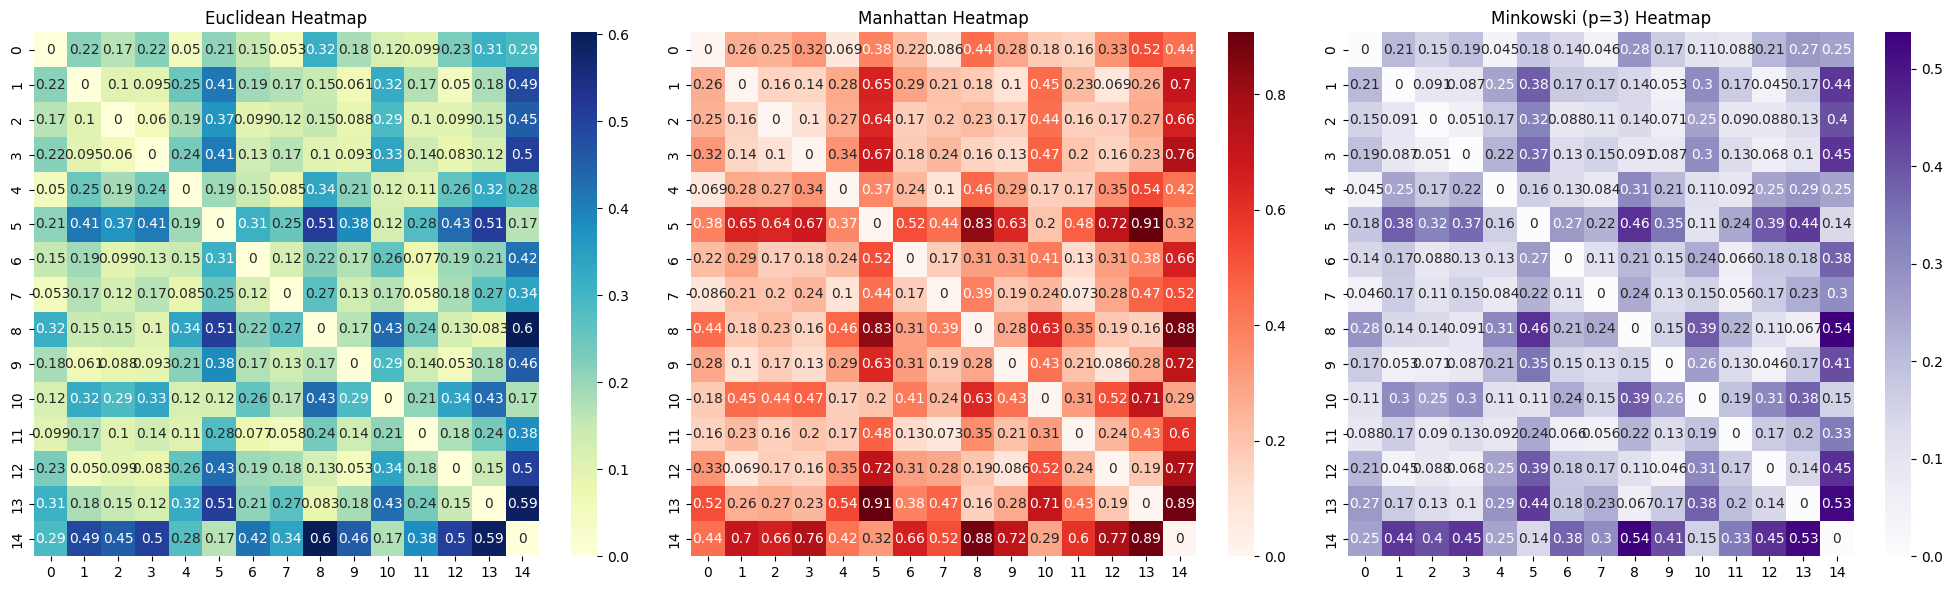

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Euclidean
sns.heatmap(dist_euclidean[:15, :15], annot=True, cmap='YlGnBu', ax=axes[0])
axes[0].set_title('Euclidean Heatmap')

# Manhattan
sns.heatmap(dist_manhattan[:15, :15], annot=True, cmap='Reds', ax=axes[1])
axes[1].set_title('Manhattan Heatmap')

# Minkowski
sns.heatmap(dist_minkowski[:15, :15], annot=True, cmap='Purples', ax=axes[2])
axes[2].set_title('Minkowski (p=3) Heatmap')

plt.tight_layout()
plt.show()

## **Kesimpulan Perhitungan**
1. **Nilai Diagonal 0:** Perhatikan bahwa diagonal matriks selalu bernilai 0. Hal ini karena jarak suatu objek terhadap dirinya sendiri adalah nol ($d(i,i) = 0$).
2. **Simetri:** Matriks ini simetris. Jarak antara objek 1 ke objek 2 sama dengan jarak objek 2 ke objek 1.
3. **Perbandingan:** Jarak Manhattan memberikan nilai yang lebih besar dibandingkan Euclidean karena menghitung selisih setiap dimensi secara linear tanpa "memotong jalan" secara diagonal.